
# Decision Tree - Cây Quyết Định

**Decision Tree (Cây quyết định)** là một thuật toán Máy học thuộc nhóm **Supervised Learning (Học có giám sát)**. Thuật toán này dự đoán dữ liệu bằng cách mô phỏng lại cách con người ra quyết định dưới dạng một cấu trúc cây đảo ngược.


## 1. Cấu Trúc Thành Phần Của Cây
Một cây quyết định hoàn chỉnh luôn bao gồm 3 thành phần chính:

* **Root Node (Nút gốc):** Nút trên cùng của cây, đại diện cho thuộc tính quan trọng nhất được chọn để phân tách dữ liệu đầu tiên.
* **Decision / Internal Node (Nút quyết định):** Các nút trung gian, đưa ra các câu hỏi hoặc điều kiện (Dạng *If-Then*) để tiếp tục rẽ nhánh dữ liệu.
* **Leaf Node (Nút lá):** Nút cuối cùng của một nhánh, chứa kết quả dự đoán (Phân loại hoặc Giá trị số) và không phân tách thêm nữa.


## 2. Các Bài Toán Giải Quyết
Decision Tree rất linh hoạt khi giải quyết được cả hai bài toán lớn trong Machine Learning:
1.  **Classification Tree (Cây phân loại):** Dự đoán nhãn rời rạc (Ví dụ: *Duyệt vay / Từ chối*, *Email Spam / Không Spam*).
2.  **Regression Tree (Cây hồi quy):** Dự đoán giá trị liên tục (Ví dụ: *Giá nhà*, *Nhiệt độ*).

## 3. Cơ Chế Phân Nhánh (Splitting Criteria)
Để chọn được câu hỏi tối ưu tại mỗi nút, thuật toán sử dụng các chỉ số toán học nhằm đo lường **độ tinh khiết (purity)** của dữ liệu sau khi chia:




* **Gini Impurity:** Đo lường độ hỗn loạn của dữ liệu. Chỉ số Gini càng nhỏ (tiến về 0), tập dữ liệu càng thuần nhất.
$$GINI = 1 - \sum_{i=1}^C{p_i^2}$$

In [1]:
import numpy as np
import model
# Giả sử file chứa class của bạn tên là decision_tree.py
data = {
    'Troi_Mua': [1, 1, 1, 0, 0, 0, 0],  # 3 ngày mưa, 7 ngày không mưa
    'Di_Choi':  [0, 0, 0, 1, 1, 1, 1]   # Kết quả thực tế (6 Yes, 4 No)
}

# Khởi tạo model
dec = model.DecisionTree()

# Truyền riêng cột nhãn 'Di_Choi' vào dưới dạng mảng Numpy hoặc List
target_y = np.array(data['Di_Choi'])
gini_value = dec._gini(target_y)

print(f"Chỉ số Gini của ĐI CHƠI thu được là: {gini_value}")

Chỉ số Gini của ĐI CHƠI thu được là: 0.48979591836734704


|Trời mưa (Y?N) | Đi chơi (Y?N) | 
| :---: | :---: |
| yes | no |
| yes | no |
| yes | no |
| no | yes |
| no | yes |
| no | yes |
| no | yes |

Đi chơi: 3 No, 4 Yes
$$Gini_{ĐI CHƠI} = 1 - \left( \frac{3}{7} \right)^2 - \left( \frac{4}{7} \right)^2 = 1 - \frac{9}{49} - \frac{16}{49} = \frac{24}{49} \approx 0.4898$$


* **Entropy & Information Gain:** Đo lường lượng thông tin thu được. Thuật toán sẽ ưu tiên chọn thuộc tính nào giúp giảm độ hỗn loạn (Entropy) nhiều nhất.
$$Entropy(S) = - \sum_{i=1}^{C} p_i \log_2(p_i)$$
$$Information\ Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Entropy(S_v)$$

In [2]:
import numpy as np
import model

# Khởi tạo mô hình cấu hình entropy
dec = model.DecisionTree(criterion='entropy')

# 1. Dữ liệu nút cha (Tổng 5 dự án: 3 bị OT, 2 không)
y_parent = np.array([1, 1, 1, 0, 0])

# 2. Dữ liệu sau khi chẻ nhánh bằng thuộc tính "Deadline gắt?"
y_left = np.array([1, 1, 0])   # Nhánh Trái: 3 dự án (2 bị OT, 1 không)
y_right = np.array([1, 0])     # Nhánh Phải: 2 dự án (1 bị OT, 1 không)

# 3. Gọi hàm tính toán Information Gain từ class tự chế của bạn
ig_value = dec._information_gain(y_parent, y_left, y_right)

print(f"Information Gain (Lượng thông tin thu được): {ig_value:.4f}")

Information Gain (Lượng thông tin thu được): 0.0200


$$Entropy(Parent) = - \left( \frac{3}{5}\log_2\frac{3}{5} + \frac{2}{5}\log_2\frac{2}{5} \right) \approx 0.9710$$
Nút con bên Trái: Có 2 mẫu lớp 1 và 1 mẫu lớp 0.$$Entropy(Left) = - \left( \frac{2}{3}\log_2\frac{2}{3} + \frac{1}{3}\log_2\frac{1}{3} \right) \approx 0.9183$$
Nút con bên Phải: Có 1 mẫu lớp 1 và 1 mẫu lớp 0 (Tỷ lệ 50/50).$$Entropy(Right) = - \left( \frac{1}{2}\log_2\frac{1}{2} + \frac{1}{2}\log_2\frac{1}{2} \right) = 1.0000$$

Bước C: Tính Information Gain tổng hợp

$$IG = Entropy(Parent) - \left[ \frac{3}{5} \times Entropy(Left) + \frac{2}{5} \times Entropy(Right) \right]$$
$$IG = 0.9710 - \left[ 0.6 \times 0.9183 + 0.4 \times 1.0000 \right]$$
$$IG = 0.9710 - \left[ 0.5510 + 0.4000 \right] = 0.9710 - 0.9510 = 0.0200$$


### Thuật toán CART (Classification And Regression Trees)

**CART** là thuật toán xây dựng cây quyết định nhị phân. Tại mỗi nút, thuật toán sẽ tìm một thuộc tính $X_i$ và một ngưỡng $t$ tối ưu nhất để phân tách dữ liệu thành hai nhánh con dựa trên điều kiện $X_i \le t$.



#### Mã giả (Pseudocode) Xây dựng Cây CART

$$
\begin{array}{l}
\textbf{Hàm } \text{CART\_Build\_Tree}(D) \\
\hline
\textbf{Đầu vào: } \text{Tập dữ liệu } D = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\} \\
\textbf{Đầu ra: } \text{Một nút của cây (Nút Quyết định hoặc Nút Lá)} \\
\hline
\textbf{1. Kiểm tra điều kiện dừng:} \\
\quad \textbf{Nếu } (\text{Tất cả nhãn } y \in D \text{ đều đồng nhất}) \textbf{ hoặc } (\text{Thỏa mãn điều kiện dừng cấu hình trước}): \\
\quad \quad \text{Tạo một } \textbf{[Nút Lá]} \text{ chứa giá trị dự đoán (Lớp phổ biến nhất hoặc Giá trị trung bình của } Y\text{)}. \\
\quad \quad \textbf{Trả về } \textbf{[Nút Lá]}. \\
\\
\textbf{2. Tìm điểm phân tách tối ưu (Best Split):} \\
\quad \text{Khởi tạo } \text{Cost}_{\text{best}} = \infty \text{ (hoặc } \text{Gain}_{\text{best}} = 0\text{)} \\
\quad \textbf{Với mỗi } \text{thuộc tính } X_i \in D: \\
\quad \quad \textbf{Với mỗi } \text{giá trị ngưỡng } t \text{ khả thi của } X_i: \\
\quad \quad \quad \text{Phân chia dữ liệu thành hai tập con:} \\
\quad \quad \quad \quad D_{\text{left}} = \{x \in D \mid x_i \le t\} \\
\quad \quad \quad \quad D_{\text{right}} = \{x \in D \mid x_i > t\} \\
\\
\quad \quad \quad \text{Tính toán độ mất mát (Impurity Cost) sau khi chia:} \\
\quad \quad \quad \quad \text{Cost} = \frac{|D_{\text{left}}|}{|D|} \text{Impurity}(D_{\text{left}}) + \frac{|D_{\text{right}}|}{|D|} \text{Impurity}(D_{\text{right}}) \\
\\
\quad \quad \quad \textbf{Nếu } \text{Cost} < \text{Cost}_{\text{best}}: \\
\quad \quad \quad \quad \text{Cost}_{\text{best}} = \text{Cost}, \quad X_{\text{best}} = X_i, \quad t_{\text{best}} = t \\
\\
\textbf{3. Phân nhánh đệ quy:} \\
\quad \textbf{Nếu } \text{không tìm được cách chia hợp lệ (Độ mất mát không giảm):} \\
\quad \quad \text{Tạo một } \textbf{[Nút Lá]} \text{ và } \textbf{Trả về}. \\
\\
\quad \text{Tạo một } \textbf{[Nút Quyết Định]} \text{ với điều kiện } (X_{\text{best}} \le t_{\text{best}}) \\
\quad \text{Nút\_Trái} = \text{CART\_Build\_Tree}(D_{\text{left}}) \\
\quad \text{Nút\_Phải} = \text{CART\_Build\_Tree}(D_{\text{right}}) \\
\\
\quad \textbf{Trả về } \textbf{[Nút Quyết Định]} \text{ đã kết nối với 2 nút con.}
\end{array}
$$

> 📌 **Ghi chú kỹ thuật:**
> * Đối với bài toán **Phân loại (Classification)**: Hàm $\text{Impurity}(D)$ được tính bằng chỉ số **Gini Impurity**: $1 - \sum (p_i)^2$.
> * Đối với bài toán **Hồi quy (Regression)**: Hàm $\text{Impurity}(D)$ được tính bằng tổng bình phương sai số **SSE**: $ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ so với giá trị trung bình.

In [ ]:
import model
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

my_tree = model.DecisionTree(min_samples=2, criterion='gini', debug=True, max_depth=10)
my_tree._build(X_train, y_train)


 [NÚT QUYẾT ĐỊNH TẦNG 0] Chọn đặc trưng cột số 9 với ngưỡng <= 3.8000
   -> Gain đạt được: 0.2708 | Tổng số mẫu hiện tại: 124
   ├─ Rẽ TRÁI (Yes): Chuyển đi 46 mẫu
   └─ Rẽ PHẢI (No) : Chuyển đi 78 mẫu

   [NÚT QUYẾT ĐỊNH TẦNG 1] Chọn đặc trưng cột số 2 với ngưỡng <= 2.9200
     -> Gain đạt được: 0.0407 | Tổng số mẫu hiện tại: 46
     ├─ Rẽ TRÁI (Yes): Chuyển đi 45 mẫu
     └─ Rẽ PHẢI (No) : Chuyển đi 1 mẫu

     [NÚT QUYẾT ĐỊNH TẦNG 2] Chọn đặc trưng cột số 11 với ngưỡng <= 3.6400
       -> Gain đạt được: 0.0435 | Tổng số mẫu hiện tại: 45
       ├─ Rẽ TRÁI (Yes): Chuyển đi 44 mẫu
       └─ Rẽ PHẢI (No) : Chuyển đi 1 mẫu

       [NÚT LÁ TẦNG 3] Tạo nút lá. Lý do: Dữ liệu tinh khiết (chỉ còn 1 nhãn)
         -> Số lượng mẫu tại lá: 44, Phân bố: {np.int64(1): np.int64(44)}
         -> Dự đoán nhãn (Bầu chọn đa số): 1

       [NÚT LÁ TẦNG 3] Tạo nút lá. Lý do: Số mẫu quá ít (1<2), Dữ liệu tinh khiết (chỉ còn 1 nhãn)
         -> Số lượng mẫu tại lá: 1, Phân bố: {np.int64(0): np.int64(1)}
 

================ BẮT ĐẦU HUẤN LUYỆN CÂY (GINI) ================
Kích thước tập Train: X=(124, 13), y=(124,)
Cấu hình: max_depth=10, min_samples=2

 [NÚT QUYẾT ĐỊNH TẦNG 0] Chọn đặc trưng cột số 9 với ngưỡng <= 3.8000
   -> Gain đạt được: 0.2708 | Tổng số mẫu hiện tại: 124
   ├─ Rẽ TRÁI (Yes): Chuyển đi 46 mẫu
   └─ Rẽ PHẢI (No) : Chuyển đi 78 mẫu

   [NÚT QUYẾT ĐỊNH TẦNG 1] Chọn đặc trưng cột số 2 với ngưỡng <= 2.9200
     -> Gain đạt được: 0.0407 | Tổng số mẫu hiện tại: 46
     ├─ Rẽ TRÁI (Yes): Chuyển đi 45 mẫu
     └─ Rẽ PHẢI (No) : Chuyển đi 1 mẫu

     [NÚT QUYẾT ĐỊNH TẦNG 2] Chọn đặc trưng cột số 11 với ngưỡng <= 3.6400
       -> Gain đạt được: 0.0435 | Tổng số mẫu hiện tại: 45
       ├─ Rẽ TRÁI (Yes): Chuyển đi 44 mẫu
       └─ Rẽ PHẢI (No) : Chuyển đi 1 mẫu

       [NÚT LÁ TẦNG 3] Tạo nút lá. Lý do: Dữ liệu tinh khiết (chỉ còn 1 nhãn)
         -> Số lượng mẫu tại lá: 44, Phân bố: {np.int64(1): np.int64(44)}
         -> Dự đoán nhãn (Bầu chọn đa số): 1

       [NÚT LÁ TẦNG 3] Tạ

C:\Users\huyz\AppData\Local\Temp\ipykernel_19128\3801040846.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


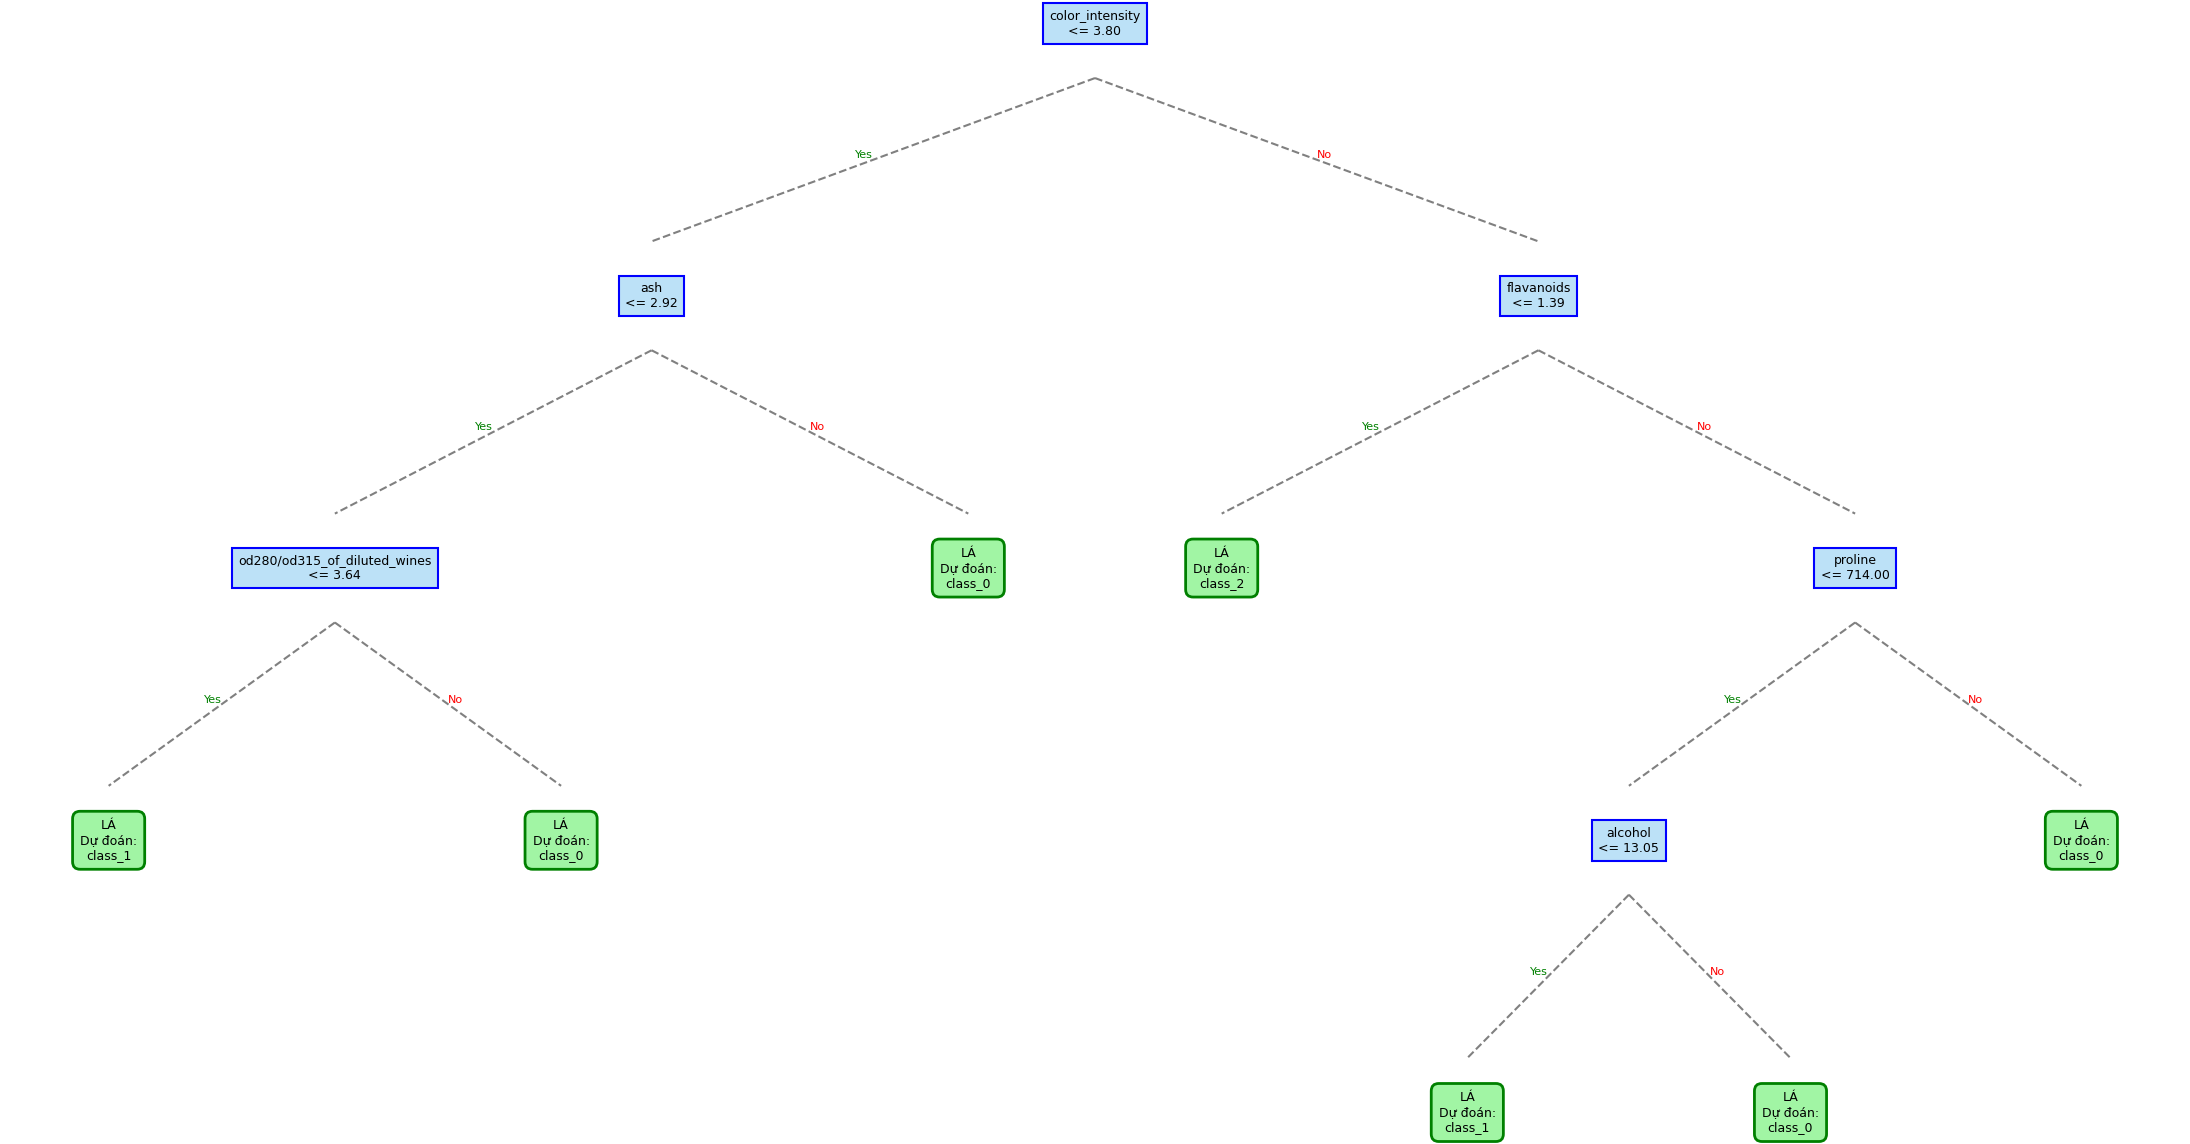

In [21]:
import matplotlib.pyplot as plt
import model
my_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(28, 14), dpi=100)
ax.axis('off') # Tắt khung lưới của đồ thị đi cho đẹp

model.plot_tree(
    node=my_tree.root,                
    feature_names=wine.feature_names, 
    class_names=wine.target_names,
    ax=ax                           
)

plt.tight_layout()
plt.show()

In [22]:
preds = my_tree.predict(X_test)
accuracy = np.sum(preds == y_test) / len(y_test)
print(f"Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

Độ chính xác trên tập Test: 94.44%


# Kết thúc